<a href="https://colab.research.google.com/github/Matteo-Raschi/Open_Data_Workshop_GW_2026/blob/main/Challenge2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
! pip install -q lalsuite gwpy pycbc
! wget https://dcc.ligo.org/public/0187/G2300818/001/challenge2.gwf


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.1/40.1 MB 19.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 57.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 77.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 300.4/300.4 kB 11.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.2/45.2 kB 1.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 168.7/168.7 kB 6.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 115.0/115.0 kB 5.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.1/51.1 kB 2.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 203.1/203.1 kB 8.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.5/51.5 kB 2.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.1/48.1 MB 14.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.7/4.7 MB 79.4 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take

/usr/lib/python3.12/importlib/__init__.py:90: UserWarning: Wswiglal-redir-stdio:

SWIGLAL standard output/error redirection is enabled in IPython.
This may lead to performance penalties. To disable locally, use:

with lal.no_swig_redirect_standard_output_error():
    ...

To disable globally, use:

lal.swig_redirect_standard_output_error(False)

Note however that this will likely lead to error messages from
LAL functions being either misdirected or lost when called from
Jupyter notebooks.

To suppress this warning, use:

import warnings
warnings.filterwarnings("ignore", "Wswiglal-redir-stdio")
import lal

  return _bootstrap._gcd_import(name[level:], package, level)


<Figure size 1000x600 with 0 Axes>

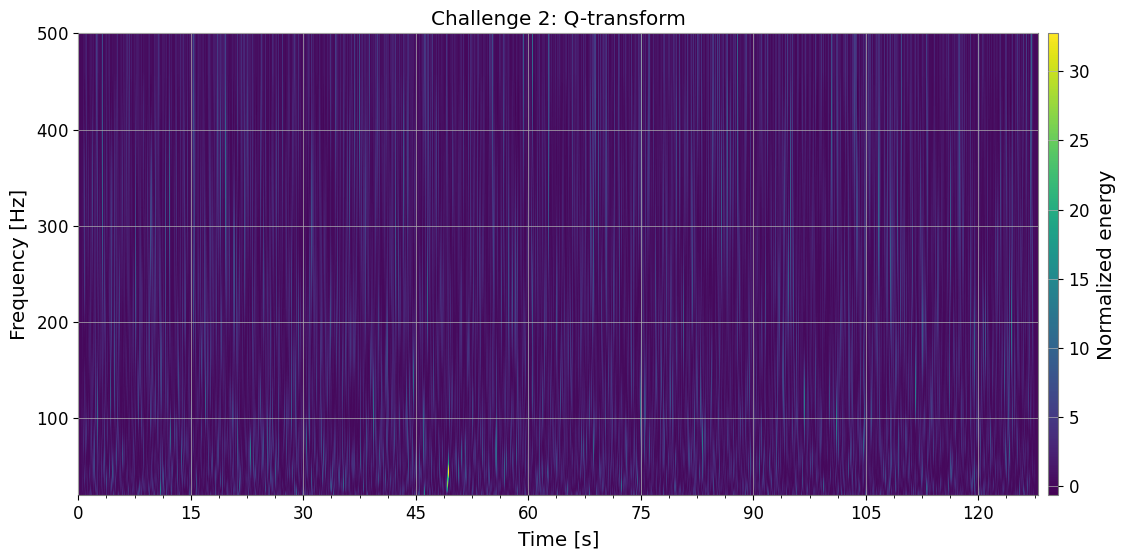

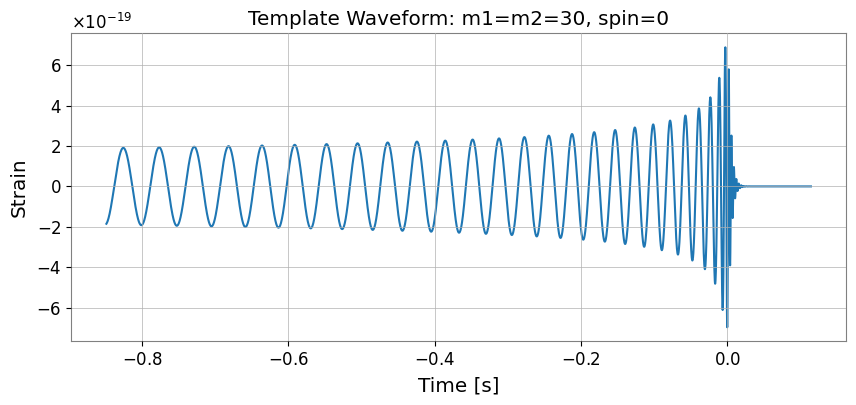

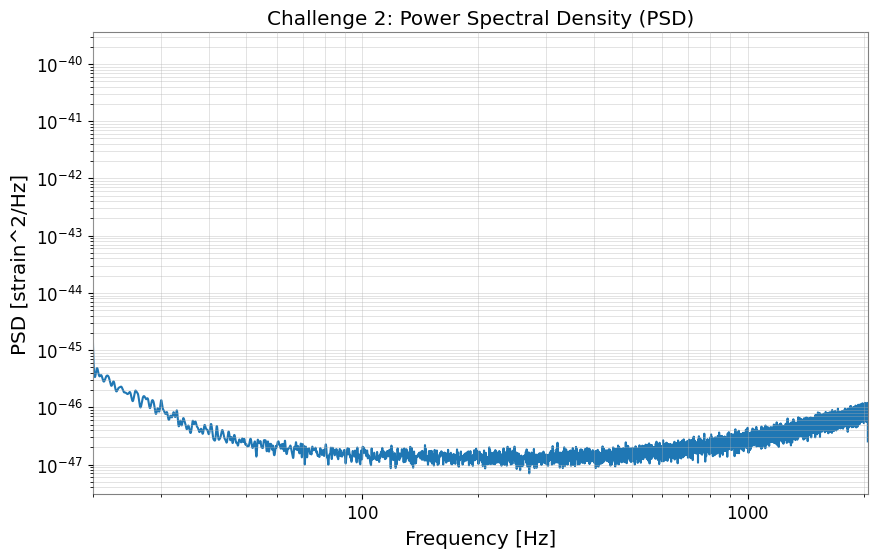

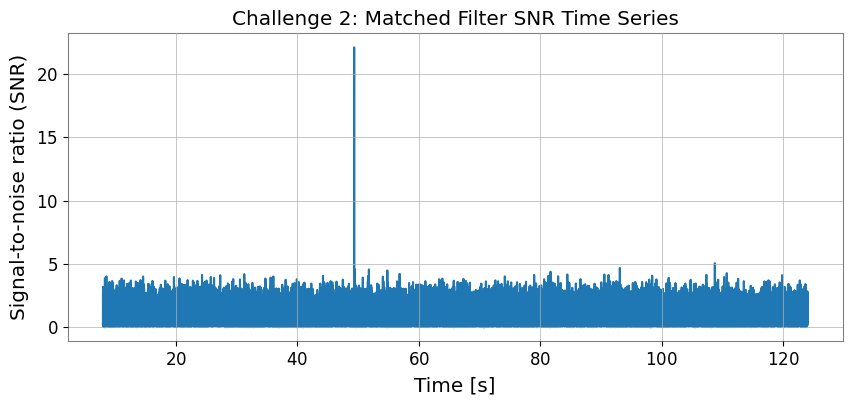

FINAL SOLUTIONS
A. Approximative time from Q-transform: ~49.28 seconds
B. Matched filter SNR of the signal:    22.08
   Precise Time of Merger (Matched Filter): 49.37 seconds from the start.


In [2]:
import pycbc.frame
from pycbc.filter import matched_filter
from pycbc.waveform import get_td_waveform
from pycbc.psd import interpolate, inverse_spectrum_truncation
import matplotlib.pyplot as plt
import numpy as np
from gwpy.timeseries import TimeSeries

data_file = 'challenge2.gwf'
channel = 'H1:CHALLENGE2'


# 1. Plot a Q-transform of the data

gwpy_strain = TimeSeries.read(data_file, channel=channel)
qspecgram = gwpy_strain.q_transform(frange=(20, 500))

plt.figure(figsize=(10, 6))
plot = qspecgram.plot()
ax = plot.gca()
ax.set_title("Challenge 2: Q-transform")
ax.set_ylabel("Frequency [Hz]")
ax.set_xlabel("Time [s]")
ax.colorbar(label="Normalized energy")
plt.show()

# Automatically find approximative merger time from the Q-transform

q_times = qspecgram.xindex.value
q_energy = qspecgram.value
max_idx = np.unravel_index(np.argmax(q_energy), q_energy.shape)
approx_time = q_times[max_idx[0]]
approx_merger_seconds = approx_time - gwpy_strain.t0.value


# 2. Generate a time-domain template waveform

pycbc_strain = pycbc.frame.read_frame(data_file, channel)
sample_rate = int(pycbc_strain.sample_rate)
nyquist_freq = sample_rate / 2.0

hp, hc = get_td_waveform(approximant="SEOBNRv4_opt",
                         mass1=30,
                         mass2=30,
                         spin1z=0,
                         spin2z=0,
                         delta_t=pycbc_strain.delta_t,
                         f_lower=20)

plt.figure(figsize=(10, 4))
plt.plot(hp.sample_times, hp)
plt.title("Template Waveform: m1=m2=30, spin=0")
plt.ylabel("Strain")
plt.xlabel("Time [s]")
plt.show()

# Resize and shift template for matched filtering

hp.resize(len(pycbc_strain))
template = hp.cyclic_time_shift(hp.start_time)


# 3. Calculate PSD and plot on log-log scale
# Calculate PSD using 4-second segments

psd = pycbc_strain.psd(4)
psd = interpolate(psd, pycbc_strain.delta_f)
psd = inverse_spectrum_truncation(psd, int(4 * pycbc_strain.sample_rate), low_frequency_cutoff=20)

plt.figure(figsize=(10, 6))
plt.loglog(psd.sample_frequencies, psd)
plt.xlim(20, nyquist_freq)
plt.title("Challenge 2: Power Spectral Density (PSD)")
plt.ylabel("PSD [strain^2/Hz]")
plt.xlabel("Frequency [Hz]")
plt.grid(True, which="both", ls="-", alpha=0.5)
plt.show()


# 4. Calculate Matched Filter SNR


snr = matched_filter(template, pycbc_strain, psd=psd, low_frequency_cutoff=20)

# Remove the beginning and end of the SNR time series to avoid filtering artifacts
snr = snr.crop(4 + 4, 4)

plt.figure(figsize=(10, 4))
plt.plot(snr.sample_times, abs(snr))
plt.title("Challenge 2: Matched Filter SNR Time Series")
plt.ylabel("Signal-to-noise ratio (SNR)")
plt.xlabel("Time [s]")
plt.show()

# Find the peak SNR to answer the questions
peak_idx = abs(snr).numpy().argmax()
peak_snr = snr[peak_idx]
precise_merger_time = snr.sample_times[peak_idx]
precise_merger_seconds = precise_merger_time - pycbc_strain.start_time


# SUMMARY / FINAL SOLUTIONS

print("=" * 60)
print("FINAL SOLUTIONS")
print("=" * 60)
print(f"A. Approximative time from Q-transform: ~{approx_merger_seconds:.2f} seconds")
print(f"B. Matched filter SNR of the signal:    {abs(peak_snr):.2f}")
print(f"   Precise Time of Merger (Matched Filter): {precise_merger_seconds:.2f} seconds from the start.")
print("=" * 60)
